# Video Emotion Recognition Model Training Pipeline

## Configuration

### Imports

In [ ]:
import os
import cv2
import numpy as np
from retinaface import RetinaFace
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

2025-11-16 08:48:36.722109: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 08:48:37.446993: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 08:48:39.510218: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Global Variables

In [ ]:
# Paths
VIDEOS_DIR = os.path.abspath('./../Datasets/Video')
PREPROCESSED_DIR = './preprocessed_data'  # Where to save processed frames
MODEL_SAVE_PATH = './models/best_video_emotion_model.h5'

# Emotion mapping
EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
EMOTION_TO_IDX = {emotion: idx for idx, emotion in enumerate(EMOTIONS.values())}
NUM_EMOTIONS_CLASSES = len(EMOTIONS)

# Video preprocessing
FRAMES_PER_VIDEO = 20
IMG_SIZE = 224
FRAME_RATE = 10

# Model architecture
LSTM_UNITS = 128
LSTM_LAYERS = 2
DROPOUT_RATE = 0.3

# Training
BATCH_SIZE = 8
EPOCHS = 80
LEARNING_RATE = 5e-5
PATIENCE = 25

## Pre-Processing

### Face detection

In [ ]:
def detect_and_crop_face(frame):
    """Detect and crop face from frame using RetinaFace"""
    RGB_Frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    Faces = RetinaFace.detect_faces(RGB_Frame)
    
    if len(Faces) > 0:
        First_Face = next(iter(Faces.values()))
        Facial_Area = First_Face["facial_area"]
        x1, y1, x2, y2 = Facial_Area
        # Add padding
        padding = 20
        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(frame.shape[1], x2 + padding)
        y2 = min(frame.shape[0], y2 + padding)
        
        face = frame[y1:y2, x1:x2]
        return face
    
    return frame


### Frames Extraction

In [4]:
def extract_frames_from_video(video_path, num_frames=16, target_size=(224, 224)):
    """Extract evenly spaced frames from video"""
    Cap = cv2.VideoCapture(video_path)
    Total_Frames = int(Cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if Total_Frames < num_frames:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    else:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    
    Frames = []
    for i in Frame_Indices:
        Cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        IsReturned, Frame = Cap.read()
        
        if IsReturned:
            Frame = detect_and_crop_face(Frame)
            Frame = cv2.resize(Frame, target_size)
            Frame = cv2.cvtColor(Frame, cv2.COLOR_BGR2RGB)
            Frames.append(Frame)
        else:
            if Frames:
                Frames.append(Frames[-1])
            else:
                Frames.append(np.zeros((target_size[0], target_size[1], 3)))
    
    Cap.release()
    return np.array(Frames)

### Preprocessing & Saving Preproccesed Data

In [ ]:
def preprocess_and_save_dataset():
    """
    Preprocess all videos and save to disk
    This only needs to be run ONCE
    """
    print("="*80)
    print("PREPROCESSING DATASET")
    print("="*80)
    
    # Create preprocessed directory
    Path(PREPROCESSED_DIR).mkdir(parents=True, exist_ok=True)
    
    metadata = []
    video_count = 0
    
    for Actor in sorted(os.listdir(VIDEOS_DIR)):
        Actor_Path = os.path.join(VIDEOS_DIR, Actor)
        
        if not os.path.isdir(Actor_Path):
            continue
        
        Video_Files = [f for f in os.listdir(Actor_Path) 
                      if f.endswith('.mp4')]
        
        print(f"\nProcessing {len(Video_Files)} videos from {Actor}")
        
        for idx, Video_File in enumerate(Video_Files):
            Video_Path = os.path.join(Actor_Path, Video_File)
            
            try:
                # Extract emotion from filename
                # Format: Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor
                parts = Video_File.split('-')
                
                if len(parts) < 3:
                    print(f"  Skipping {Video_File}: Invalid filename format")
                    continue
                
                emotion_code = parts[2]
                emotion_name = EMOTIONS.get(emotion_code)
                
                if emotion_name is None:
                    print(f"  Skipping {Video_File}: Unknown emotion code {emotion_code}")
                    continue
                
                emotion_idx = EMOTION_TO_IDX[emotion_name]
                
                # Extract and process frames
                frames = extract_frames_from_video(
                    Video_Path,
                    num_frames=FRAMES_PER_VIDEO,
                    target_size=(IMG_SIZE, IMG_SIZE)
                )
                
                # Normalize
                frames = frames.astype(np.float32) / 255.0
                
                # Save preprocessed frames
                save_path = os.path.join(PREPROCESSED_DIR, f"video_{video_count:05d}.npy")
                np.save(save_path, frames)
                
                # Store metadata
                metadata.append((save_path, emotion_idx, emotion_name))
                video_count += 1
                
                if (idx + 1) % 10 == 0:
                    print(f"  Processed {idx + 1}/{len(Video_Files)} videos")
                
            except Exception as e:
                print(f"  Error processing {Video_File}: {e}")
                continue
    
    # Save metadata
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    
    print(f"\n{'='*80}")
    print(f"PREPROCESSING COMPLETE!")
    print(f"Total videos processed: {video_count}")
    print(f"Metadata saved to: {metadata_path}")
    
    # Print emotion distribution
    from collections import Counter
    emotion_labels = [item[1] for item in metadata]
    emotion_counts = Counter(emotion_labels)
    print(f"\nEmotion distribution:")
    emotion_names = list(EMOTIONS.values())
    for label, count in sorted(emotion_counts.items()):
        print(f"  {emotion_names[label]}: {count} videos")
    
    print(f"{'='*80}\n")
    
    return metadata

## Data Augmentation & Batch Processing

In [ ]:
def augment_frame(frame):
    """Apply random augmentations to frame"""
    # Random horizontal flip
    if np.random.random() > 0.5:
        frame = cv2.flip(frame, 1)
    
    # Random brightness adjustment
    brightness_factor = np.random.uniform(0.7, 1.3)
    frame = np.clip(frame * brightness_factor, 0, 1)
    
    # Random contrast adjustment
    contrast_factor = np.random.uniform(0.8, 1.2)
    mean = frame.mean()
    frame = np.clip((frame - mean) * contrast_factor + mean, 0, 1)
    
    # Small random rotation (-15 to +15 degrees)
    angle = np.random.uniform(-15, 15)
    h, w = frame.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    frame = cv2.warpAffine(frame, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    return frame


class VideoDataGenerator(tf.keras.utils.Sequence):
    """
    Custom data generator that loads preprocessed videos in batches
    with data augmentation for training
    """
    
    def __init__(self, file_paths, labels, batch_size=8, shuffle=True, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()
    
    def __len__(self):
        """Number of batches per epoch"""
        return int(np.ceil(len(self.file_paths) / self.batch_size))
    
    def __getitem__(self, index):
        """Get one batch of data"""
        # Get batch indices
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.file_paths))
        batch_indices = self.indices[start_idx:end_idx]
        
        # Load batch data
        batch_videos = []
        batch_labels = []
        
        for idx in batch_indices:
            # Load preprocessed video
            video = np.load(self.file_paths[idx])
            
            # Apply augmentation if enabled
            if self.augment:
                video = np.array([augment_frame(frame) for frame in video])
            
            batch_videos.append(video)
            batch_labels.append(self.labels[idx])
        
        return np.array(batch_videos), np.array(batch_labels)
    
    def on_epoch_end(self):
        """Shuffle data after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)


def load_preprocessed_metadata():
    """Load metadata from preprocessed dataset"""
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')
    
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(
            f"Metadata not found at {metadata_path}. "
            "Please run preprocess_and_save_dataset() first."
        )
    
    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)
    
    file_paths = [item[0] for item in metadata]
    labels = [item[1] for item in metadata]
    
    return file_paths, labels


## Model Building & Training

### Building

Architecture: <br>
    1. ResNet50 (pre-trained) extracts spatial features from each frame <br>
    2. Bi-LSTM processes temporal sequence <br>
    3. Attention mechanism focuses on important frames <br>
    4. Classification head <br>

In [ ]:
def build_model():
    """Build CNN-LSTM model with attention"""
    print("Building model...")
    
    tf.keras.backend.clear_session()
    
    Model_Input_Layer = layers.Input(shape=(FRAMES_PER_VIDEO, IMG_SIZE, IMG_SIZE, 3))

    Base_CNN = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    
    for Layer in Base_CNN.layers[:-20]:
        Layer.trainable = False
    
    CNN_Features = layers.TimeDistributed(Base_CNN)(Model_Input_Layer)
    CNN_Features = layers.Dropout(DROPOUT_RATE)(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.01))
    )(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.01))
    )(LSTM_Out)
    
    # Attention Mechanism
    Attention_Layer = layers.Dense(1, activation='tanh')(LSTM_Out)
    Attention_Layer = layers.Flatten()(Attention_Layer)
    Attention_Layer = layers.Activation('softmax')(Attention_Layer)
    Attention_Layer = layers.RepeatVector(2 * LSTM_UNITS)(Attention_Layer)
    Attention_Layer = layers.Permute([2, 1])(Attention_Layer)
    
    attended = layers.Multiply()([LSTM_Out, Attention_Layer])
    attended = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(attended)
    
    # Classification Head
    x = layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(0.01))(attended)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    x = layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    Model_Output_Layer = layers.Dense(NUM_EMOTIONS_CLASSES, activation='softmax')(x)
    
    Model = tf.keras.Model(inputs=Model_Input_Layer, outputs=Model_Output_Layer,
                          name='Video_Emotion_Recognition')
    Model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy')
        ]
    )
    
    return Model

### Training

In [ ]:
def train_model():
    """Train the model using batch generators"""
    print("="*80)
    print("LOADING PREPROCESSED DATA")
    print("="*80)
    
    # Load metadata
    file_paths, labels = load_preprocessed_metadata()
    print(f"Loaded {len(file_paths)} preprocessed videos")
    
    # Split data
    file_paths_train, file_paths_temp, labels_train, labels_temp = train_test_split(
        file_paths, labels, test_size=0.25, random_state=42, stratify=labels
    )
    file_paths_val, file_paths_test, labels_val, labels_test = train_test_split(
        file_paths_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp
    )
    
    print(f"\nDataset split:")
    print(f"  Train: {len(file_paths_train)} videos")
    print(f"  Validation: {len(file_paths_val)} videos")
    print(f"  Test: {len(file_paths_test)} videos")
    
    # Compute class weights
    Class_Weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels_train),
        y=labels_train
    )
    Class_Weights = dict(enumerate(Class_Weights))
    
    # Create data generators
    train_gen = VideoDataGenerator(file_paths_train, labels_train, 
                                   batch_size=BATCH_SIZE, shuffle=True)
    val_gen = VideoDataGenerator(file_paths_val, labels_val, 
                                 batch_size=BATCH_SIZE, shuffle=False)
    test_gen = VideoDataGenerator(file_paths_test, labels_test, 
                                  batch_size=BATCH_SIZE, shuffle=False)
    
    # Build model
    model = build_model()
    print("\n" + "="*80)
    print("MODEL ARCHITECTURE")
    print("="*80)
    model.summary()
    
    # Callbacks
    Path('./models').mkdir(exist_ok=True)
    callbacks = [
        ModelCheckpoint(
            MODEL_SAVE_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    # Train
    print("\n" + "="*80)
    print("TRAINING")
    print("="*80)
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=Class_Weights,
        verbose=1
    )
    
    return model, history, test_gen, labels_test


## Evaluation & Visualization

In [ ]:
def evaluate_model(model, test_gen, labels_test):
    """Evaluate model on test set"""
    print("\n" + "="*80)
    print("EVALUATION")
    print("="*80)
    
    # Predictions
    predictions = model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get unique classes present in test set
    unique_labels = np.unique(labels_test)
    emotion_names = list(EMOTIONS.values())
    present_emotion_names = [emotion_names[i] for i in unique_labels]
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(labels_test, predicted_classes, 
                               labels=unique_labels,
                               target_names=present_emotion_names))
    
    # Confusion matrix
    cm = confusion_matrix(labels_test, predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_emotion_names,
                yticklabels=present_emotion_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('./models/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for i, emotion_idx in enumerate(unique_labels):
        emotion = emotion_names[emotion_idx]
        print(f"  {emotion}: {class_accuracy[i]:.2%}")


def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('./models/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

## Main Execution

Preprocessed data found. Skipping preprocessing.
(Delete ./preprocessed_data to reprocess)

LOADING PREPROCESSED DATA
Loaded 1306 preprocessed videos

Dataset split:
  Train: 979 videos
  Validation: 163 videos
  Test: 164 videos
Building model...


2025-11-15 22:30:36.132929: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1763238636.133006    1214 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6073 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:2d:00.0, compute capability: 7.5



MODEL ARCHITECTURE
Model: "Video_Emotion_Recognition"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20, 224, 224, 3)]    0         []                            
                                                                                                  
 time_distributed (TimeDist  (None, 20, 2048)             2358771   ['input_1[0][0]']             
 ributed)                                                 2                                       
                                                                                                  
 dropout (Dropout)           (None, 20, 2048)             0         ['time_distributed[0][0]']    
                                                                                                  
 bidirectional (Bidirection  (None, 20, 256)          

2025-11-15 22:30:49.546774: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-11-15 22:30:56.966045: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2025-11-15 22:30:59.244798: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f058c13fb40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-15 22:30:59.244846: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 SUPER, C

123/123 [==============================] - ETA: 0s - loss: 2.8177 - accuracy: 0.1614 - top_2_accuracy: 0.2543
Epoch 1: val_accuracy improved from -inf to 0.13497, saving model to ./models/best_video_emotion_model.h5
123/123 [==============================] - 253s 2s/step - loss: 2.8177 - accuracy: 0.1614 - top_2_accuracy: 0.2543 - val_loss: 2.1240 - val_accuracy: 0.1350 - val_top_2_accuracy: 0.0000e+00 - lr: 5.0000e-05
Epoch 2/80


...

123/123 [==============================] - ETA: 0s - loss: 0.3892 - accuracy: 0.8652 - top_2_accuracy: 0.1777
Epoch 46: val_accuracy did not improve from 0.93252
123/123 [==============================] - 140s 1s/step - loss: 0.3892 - accuracy: 0.8652 - top_2_accuracy: 0.1777 - val_loss: 0.2672 - val_accuracy: 0.8834 - val_top_2_accuracy: 0.1595 - lr: 3.1250e-06
Epoch 47/80
123/123 [==============================] - ETA: 0s - loss: 0.4144 - accuracy: 0.8590 - top_2_accuracy: 0.1869
Epoch 47: val_accuracy did not improve from 0.93252
123/123 [==============================] - 140s 1s/step - loss: 0.4144 - accuracy: 0.8590 - top_2_accuracy: 0.1869 - val_loss: 0.2563 - val_accuracy: 0.9141 - val_top_2_accuracy: 0.1779 - lr: 3.1250e-06
Epoch 48/80
123/123 [==============================] - ETA: 0s - loss: 0.3855 - accuracy: 0.8733 - top_2_accuracy: 0.1818
Epoch 48: val_accuracy did not improve from 0.93252
123/123 [==============================] - 139s 1s/step - loss: 0.3855 - accuracy: 0

2025-11-16 01:10:34.708097: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 96337984 bytes after encountering the first element of size 96337984 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


123/123 [==============================] - ETA: 0s - loss: 0.2761 - accuracy: 0.8999 - top_2_accuracy: 0.1879
Epoch 62: val_accuracy did not improve from 0.95092
123/123 [==============================] - 128s 1s/step - loss: 0.2761 - accuracy: 0.8999 - top_2_accuracy: 0.1879 - val_loss: 0.1500 - val_accuracy: 0.9448 - val_top_2_accuracy: 0.1043 - lr: 1.5625e-06
Epoch 63/80
123/123 [==============================] - ETA: 0s - loss: 0.2721 - accuracy: 0.9213 - top_2_accuracy: 0.1828
Epoch 63: val_accuracy did not improve from 0.95092
123/123 [==============================] - 129s 1s/step - loss: 0.2721 - accuracy: 0.9213 - top_2_accuracy: 0.1828 - val_loss: 0.2383 - val_accuracy: 0.9202 - val_top_2_accuracy: 0.2883 - lr: 1.5625e-06
Epoch 64/80
123/123 [==============================] - ETA: 0s - loss: 0.2353 - accuracy: 0.9213 - top_2_accuracy: 0.1869
Epoch 64: val_accuracy did not improve from 0.95092
123/123 [==============================] - 130s 1s/step - loss: 0.2353 - accuracy: 0

2025-11-16 01:42:08.535879: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 96337984 bytes after encountering the first element of size 96337984 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


123/123 [==============================] - ETA: 0s - loss: 0.1813 - accuracy: 0.9428 - top_2_accuracy: 0.1788
Epoch 77: val_accuracy did not improve from 0.97546
123/123 [==============================] - 130s 1s/step - loss: 0.1813 - accuracy: 0.9428 - top_2_accuracy: 0.1788 - val_loss: 0.0732 - val_accuracy: 0.9693 - val_top_2_accuracy: 0.2025 - lr: 7.8125e-07
Epoch 78/80
123/123 [==============================] - ETA: 0s - loss: 0.1924 - accuracy: 0.9336 - top_2_accuracy: 0.2033
Epoch 78: val_accuracy did not improve from 0.97546
123/123 [==============================] - 125s 1s/step - loss: 0.1924 - accuracy: 0.9336 - top_2_accuracy: 0.2033 - val_loss: 0.1059 - val_accuracy: 0.9693 - val_top_2_accuracy: 0.1043 - lr: 7.8125e-07
Epoch 79/80
123/123 [==============================] - ETA: 0s - loss: 0.1990 - accuracy: 0.9356 - top_2_accuracy: 0.1859
Epoch 79: val_accuracy did not improve from 0.97546
123/123 [==============================] - 125s 1s/step - loss: 0.1990 - accuracy: 0

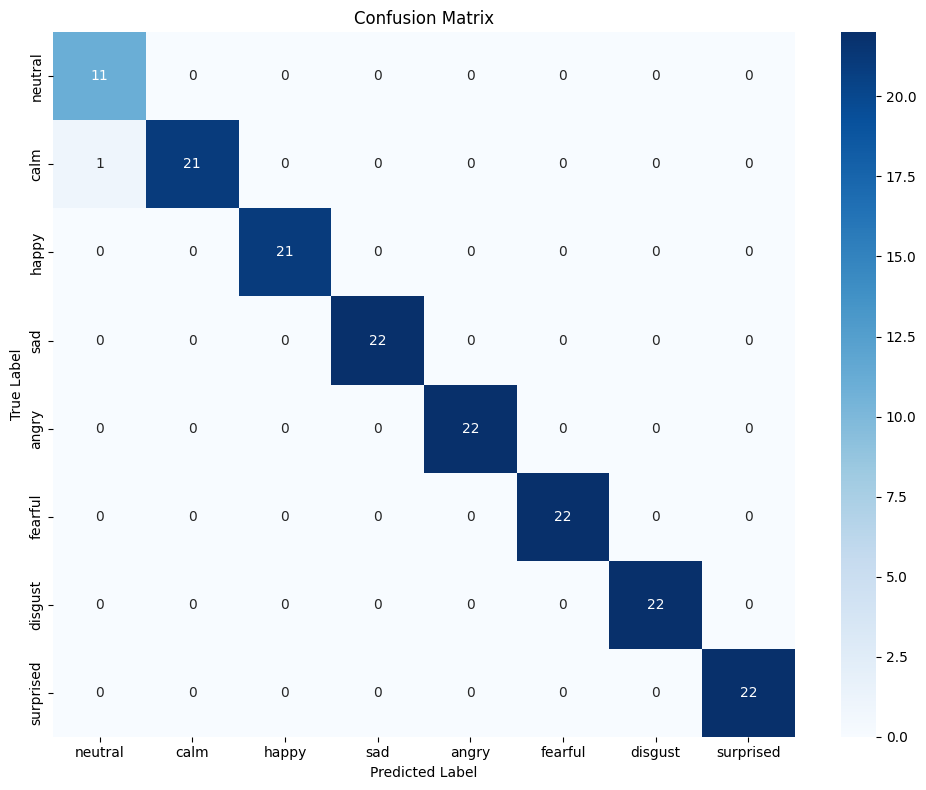


Per-Class Accuracy:
  neutral: 100.00%
  calm: 95.45%
  happy: 100.00%
  sad: 100.00%
  angry: 100.00%
  fearful: 100.00%
  disgust: 100.00%
  surprised: 100.00%


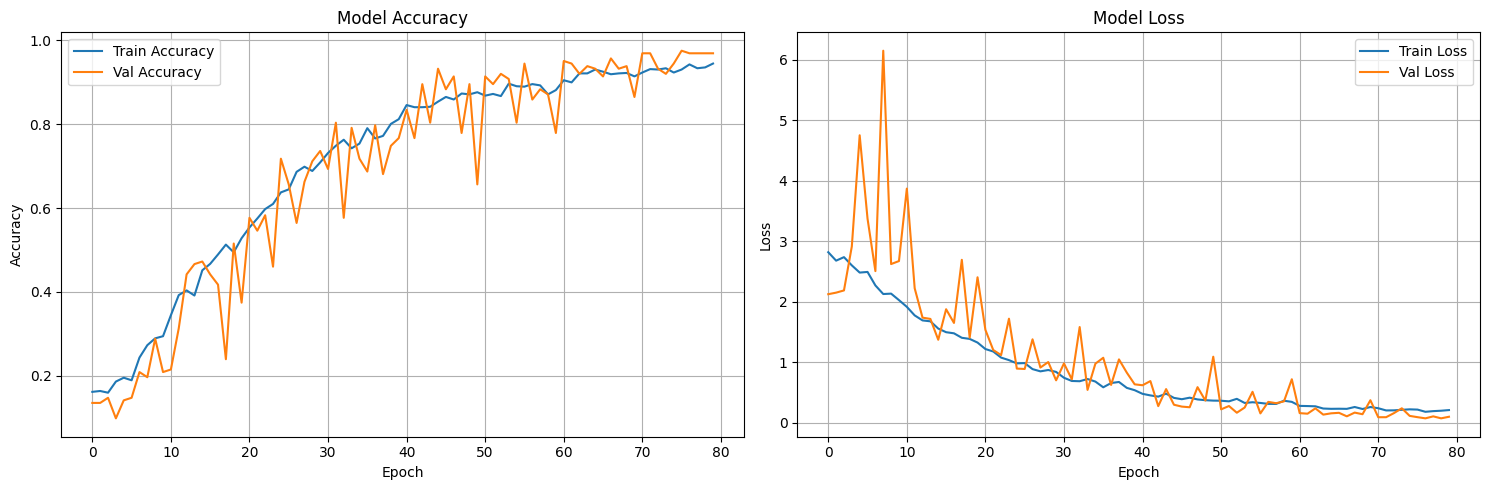


COMPLETE!


In [ ]:
# Clear any cached models
import tensorflow as tf
tf.keras.backend.clear_session()

# Force garbage collection
import gc
gc.collect()

if __name__ == "__main__":
    # Step 1: Preprocess (run only once)
    if not os.path.exists(os.path.join(PREPROCESSED_DIR, 'metadata.pkl')):
        print("No preprocessed data found. Starting preprocessing...")
        preprocess_and_save_dataset()
    else:
        print("Preprocessed data found. Skipping preprocessing.")
        print("(Delete ./preprocessed_data to reprocess)\n")
    
    # Step 2: Train model
    model, history, test_gen, labels_test = train_model()
    
    # Step 3: Evaluate
    evaluate_model(model, test_gen, labels_test)
    plot_training_history(history)
    
    print("\n" + "="*80)
    print("COMPLETE!")
    print("="*80)

## Data Balance Checking

DATA BALANCE ANALYSIS

📊 Total videos: 1306
📊 Number of emotion classes: 8

------------------------------------------------------------
Emotion         Count      Percentage   Balance
------------------------------------------------------------
neutral         87           6.66%      ⚠️  Under-represented
calm            175         13.40%      ✓ Balanced
happy           173         13.25%      ✓ Balanced
sad             175         13.40%      ✓ Balanced
angry           172         13.17%      ✓ Balanced
fearful         175         13.40%      ✓ Balanced
disgust         175         13.40%      ✓ Balanced
surprised       174         13.32%      ✓ Balanced
------------------------------------------------------------

📈 Statistical Summary:
   Mean samples per class: 163.25
   Std deviation: 28.84
   Min samples: 87
   Max samples: 175
   Imbalance ratio (max/min): 2.01

💡 Interpretation:
   ⚠️  Dataset is MODERATELY IMBALANCED (1.5 < ratio ≤ 3.0)
   → Using class weights (already imple

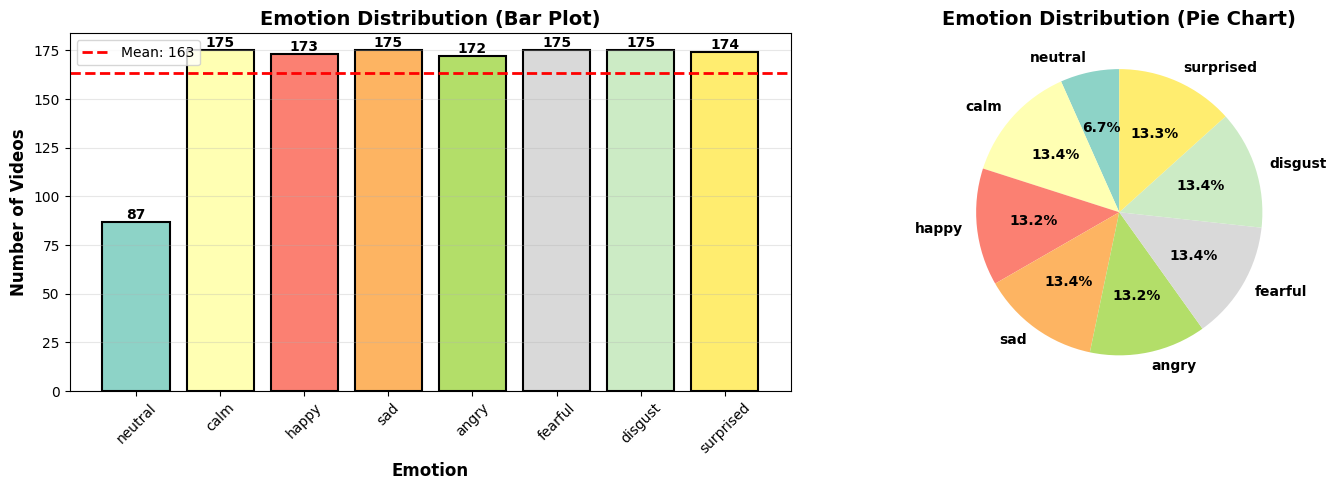

In [ ]:
def check_data_balance(show_plot=True):
    """
    Check if the dataset is balanced across emotion classes
    """
    import pickle
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np
    
    print("="*80)
    print("DATA BALANCE ANALYSIS")
    print("="*80)
    
    # Load metadata
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata.pkl')
    
    if not os.path.exists(metadata_path):
        print("❌ No preprocessed data found. Run preprocessing first!")
        return
    
    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)
    
    # Extract labels
    labels = [item[1] for item in metadata]
    emotion_names_list = list(EMOTIONS.values())
    
    # Count emotions
    emotion_counts = Counter(labels)
    total_videos = len(labels)
    
    print(f"\n📊 Total videos: {total_videos}")
    print(f"📊 Number of emotion classes: {len(emotion_counts)}")
    print("\n" + "-"*60)
    print(f"{'Emotion':<15} {'Count':<10} {'Percentage':<12} {'Balance'}")
    print("-"*60)
    
    # Calculate statistics
    counts = []
    for label in sorted(emotion_counts.keys()):
        emotion = emotion_names_list[label]
        count = emotion_counts[label]
        percentage = (count / total_videos) * 100
        counts.append(count)
        
        # Determine balance status
        if percentage > 15:  # More than 15% for 8 classes
            balance = "✅ Over-represented"
        elif percentage < 10:  # Less than 10% for 8 classes
            balance = "⚠️  Under-represented"
        else:
            balance = "✓ Balanced"
        
        print(f"{emotion:<15} {count:<10} {percentage:>6.2f}%      {balance}")
    
    print("-"*60)
    
    # Statistical analysis
    counts_array = np.array(counts)
    mean_count = np.mean(counts_array)
    std_count = np.std(counts_array)
    min_count = np.min(counts_array)
    max_count = np.max(counts_array)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n📈 Statistical Summary:")
    print(f"   Mean samples per class: {mean_count:.2f}")
    print(f"   Std deviation: {std_count:.2f}")
    print(f"   Min samples: {min_count}")
    print(f"   Max samples: {max_count}")
    print(f"   Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    
    # Interpretation
    print(f"\n💡 Interpretation:")
    if imbalance_ratio <= 1.5:
        print("   ✅ Dataset is WELL BALANCED (ratio ≤ 1.5)")
        print("   → No special handling needed")
    elif imbalance_ratio <= 3.0:
        print("   ⚠️  Dataset is MODERATELY IMBALANCED (1.5 < ratio ≤ 3.0)")
        print("   → Using class weights (already implemented) is recommended")
    else:
        print("   ❌ Dataset is HIGHLY IMBALANCED (ratio > 3.0)")
        print("   → Consider data augmentation or advanced techniques")
    
    print("="*80)
    
    # Visualization
    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Bar plot
        emotions = [emotion_names_list[label] for label in sorted(emotion_counts.keys())]
        counts_list = [emotion_counts[label] for label in sorted(emotion_counts.keys())]
        colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))
        
        bars = ax1.bar(emotions, counts_list, color=colors, edgecolor='black', linewidth=1.5)
        ax1.axhline(y=mean_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_count:.0f}')
        ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Number of Videos', fontsize=12, fontweight='bold')
        ax1.set_title('Emotion Distribution (Bar Plot)', fontsize=14, fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Pie chart
        ax2.pie(counts_list, labels=emotions, autopct='%1.1f%%', 
                colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
        ax2.set_title('Emotion Distribution (Pie Chart)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot
        plot_path = os.path.join(PREPROCESSED_DIR, 'data_balance_analysis.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n💾 Plot saved to: {plot_path}")
        plt.show()
    
    return emotion_counts

# Run the balance check
if os.path.exists(os.path.join(PREPROCESSED_DIR, 'metadata.pkl')):
    check_data_balance(show_plot=True)
else:
    print("⚠️  No preprocessed data found. Run preprocessing first!")